In [1]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

plt.style.use('fivethirtyeight')

In [3]:
end = datetime.now()
start = datetime(end.year-15, end.month, end.day)

stock = 'ETH-USD'   # Ethereum

stock_data = yf.download(stock, start=start, end=end)

C:\Users\Soham Rajapurkar\AppData\Local\Temp\ipykernel_2408\2073840722.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(stock, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


In [4]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,ETH-USD,ETH-USD,ETH-USD,ETH-USD,ETH-USD
Date,,,,,
2017-11-09,320.884003,329.451996,307.056000,308.644989,893249984
2017-11-10,299.252991,324.717987,294.541992,320.670990,885985984
2017-11-11,314.681000,319.453003,298.191986,298.585999,842300992
2017-11-12,307.907990,319.153015,298.513000,314.690002,1613479936
2017-11-13,316.716003,328.415009,307.024994,307.024994,1041889984


In [5]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,ETH-USD,ETH-USD,ETH-USD,ETH-USD,ETH-USD
Date,,,,,
2017-11-09,320.884003,329.451996,307.056000,308.644989,893249984
2017-11-10,299.252991,324.717987,294.541992,320.670990,885985984
2017-11-11,314.681000,319.453003,298.191986,298.585999,842300992
2017-11-12,307.907990,319.153015,298.513000,314.690002,1613479936
2017-11-13,316.716003,328.415009,307.024994,307.024994,1041889984


In [6]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,ETH-USD,ETH-USD,ETH-USD,ETH-USD,ETH-USD
Date,,,,,
2017-11-09,320.884003,329.451996,307.056000,308.644989,893249984
2017-11-10,299.252991,324.717987,294.541992,320.670990,885985984
2017-11-11,314.681000,319.453003,298.191986,298.585999,842300992
2017-11-12,307.907990,319.153015,298.513000,314.690002,1613479936
2017-11-13,316.716003,328.415009,307.024994,307.024994,1041889984


In [7]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3046 entries, 2017-11-09 to 2026-03-12
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, ETH-USD)   3046 non-null   float64
 1   (High, ETH-USD)    3046 non-null   float64
 2   (Low, ETH-USD)     3046 non-null   float64
 3   (Open, ETH-USD)    3046 non-null   float64
 4   (Volume, ETH-USD)  3046 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 142.8 KB


In [8]:
closing_price = stock_data[['Close']]

In [9]:
closing_price["Close"]

Ticker,ETH-USD
Date,
2017-11-09,320.884003
2017-11-10,299.252991
2017-11-11,314.681000
2017-11-12,307.907990
2017-11-13,316.716003
...,...
2026-03-08,1936.604736
2026-03-09,1992.938232
2026-03-10,2037.120483


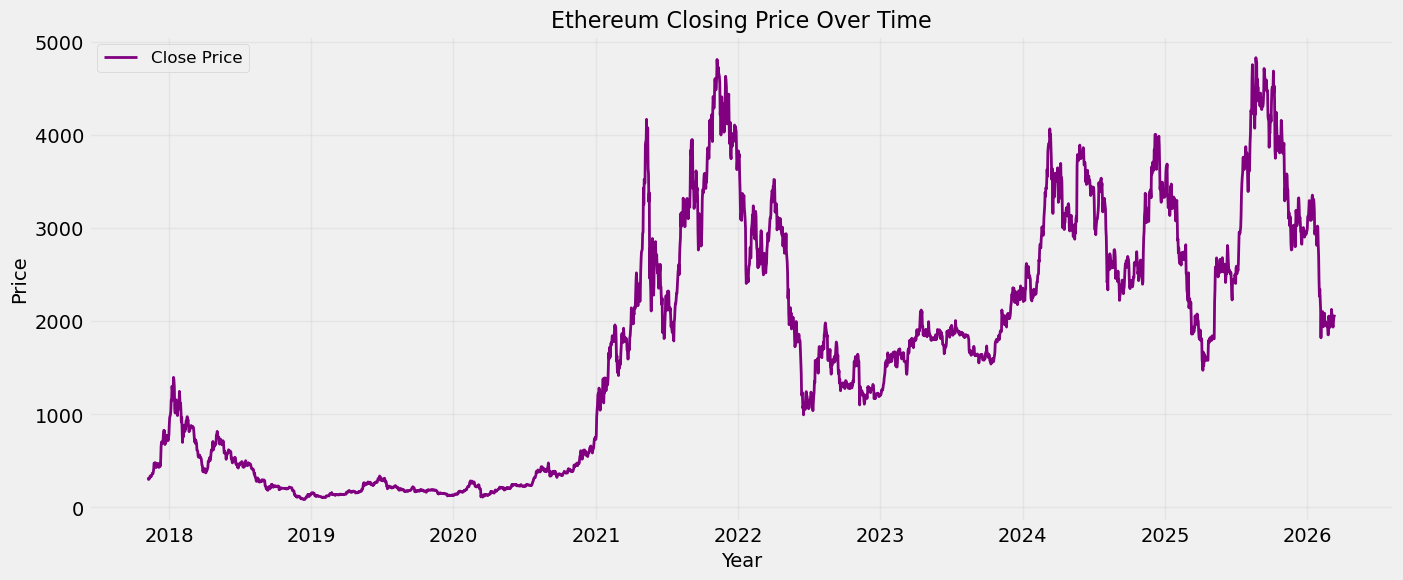

In [10]:
plt.figure(figsize=(15,6))
plt.plot(closing_price.index, closing_price['Close'], label='Close Price', color='purple', linewidth=2)

plt.title("Ethereum Closing Price Over Time", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Price", fontsize=14)

plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

In [11]:
closing_price['MA_365'] = closing_price['Close'].rolling(window=365).mean()
closing_price['MA_100'] = closing_price['Close'].rolling(window=100).mean()

C:\Users\Soham Rajapurkar\AppData\Local\Temp\ipykernel_2408\2942381381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_365'] = closing_price['Close'].rolling(window=365).mean()
C:\Users\Soham Rajapurkar\AppData\Local\Temp\ipykernel_2408\2942381381.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_100'] = closing_price['Close'].rolling(window=100).mean()


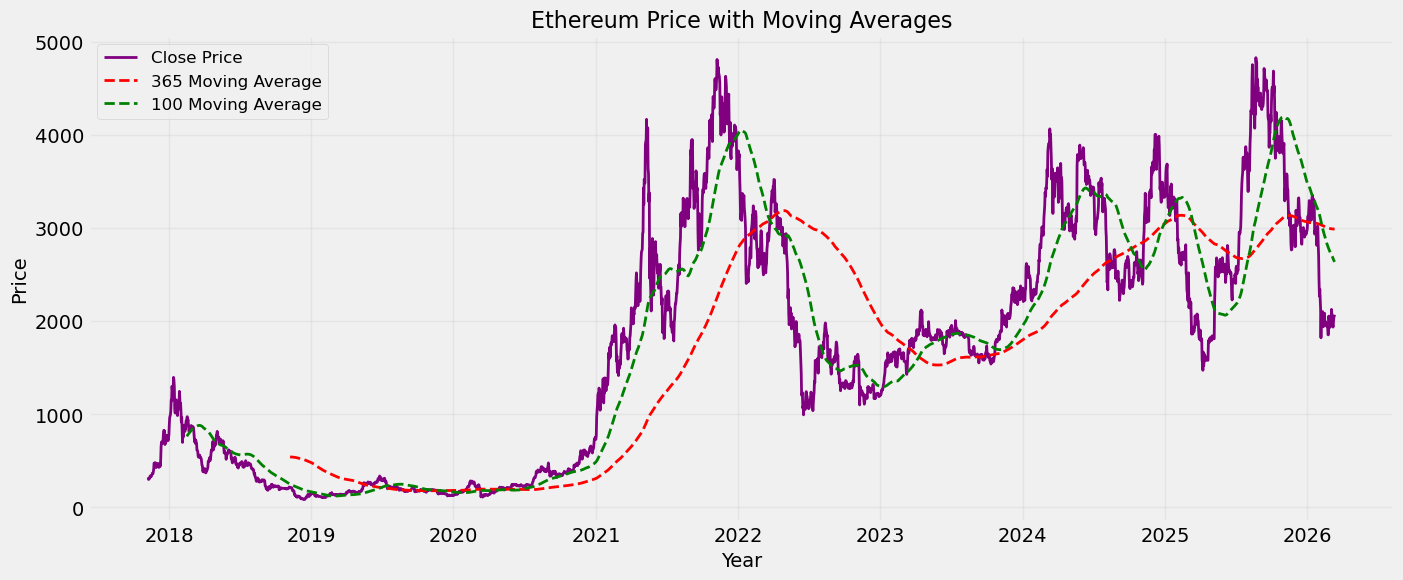

In [12]:
plt.figure(figsize=(15,6))

plt.plot(closing_price.index, closing_price['Close'], label='Close Price', color='purple', linewidth=2)
plt.plot(closing_price.index, closing_price['MA_365'], label='365 Moving Average', color='red', linestyle="--", linewidth=2)
plt.plot(closing_price.index, closing_price['MA_100'], label='100 Moving Average', color='green', linestyle="--", linewidth=2)

plt.title("Ethereum Price with Moving Averages", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Price", fontsize=14)

plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(closing_price[['Close']].dropna())

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(closing_price[['Close']].dropna())

In [15]:
len(scaled_data)

3046

In [16]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [17]:
x_data = []
y_data = []

base_days = 100

for i in range(base_days, len(scaled_data)):
    x_data.append(scaled_data[i-base_days:i])
    y_data.append(scaled_data[i])

x_data = np.array(x_data)
y_data = np.array(y_data)

In [18]:
train_size = int(len(x_data)*0.9)

x_train, y_train = x_data[:train_size], y_data[:train_size]
x_test, y_test = x_data[train_size:], y_data[train_size:]

In [19]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(x_train.shape[1],1)),
    LSTM(64, return_sequences=False),
    Dense(25),
    Dense(1)
])

model.compile(optimizer="adam", loss="mean_squared_error")

model.summary()

C:\Users\Soham Rajapurkar\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 117,619 (459.45 KB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.fit(x_train, y_train, batch_size=5, epochs=10)

Epoch 1/10
531/531 ━━━━━━━━━━━━━━━━━━━━ 58s 90ms/step - loss: 0.0051
Epoch 2/10
531/531 ━━━━━━━━━━━━━━━━━━━━ 45s 86ms/step - loss: 0.0010
Epoch 3/10
531/531 ━━━━━━━━━━━━━━━━━━━━ 46s 87ms/step - loss: 6.3452e-04
Epoch 4/10
531/531 ━━━━━━━━━━━━━━━━━━━━ 46s 86ms/step - loss: 4.4111e-04
Epoch 5/10
531/531 ━━━━━━━━━━━━━━━━━━━━ 46s 86ms/step - loss: 5.3025e-04
Epoch 6/10
531/531 ━━━━━━━━━━━━━━━━━━━━ 45s 85ms/step - loss: 4.8627e-04
Epoch 7/10
531/531 ━━━━━━━━━━━━━━━━━━━━ 46s 87ms/step - loss: 4.8135e-04
Epoch 8/10
531/531 ━━━━━━━━━━━━━━━━━━━━ 46s 87ms/step - loss: 4.0995e-04
Epoch 9/10
531/531 ━━━━━━━━━━━━━━━━━━━━ 46s 86ms/step - loss: 4.4232e-04
Epoch 10/10
531/531 ━━━━━━━━━━━━━━━━━━━━ 47s 88ms/step - loss: 4.8120e-04


In [21]:
prediction = model.predict(x_test)

inv_predictions = scaler.inverse_transform(prediction)
inverse_y_test = scaler.inverse_transform(y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step


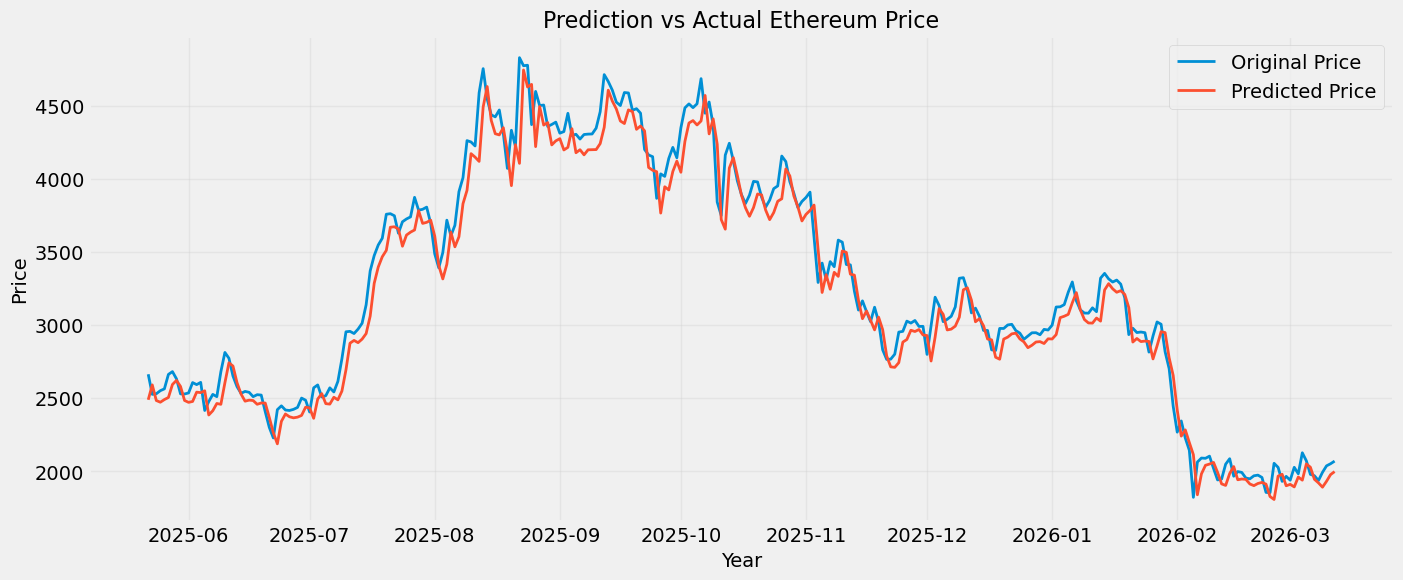

In [22]:
plotting_data = pd.DataFrame(
    {
        'Original': inverse_y_test.flatten(),
        'Prediction': inv_predictions.flatten(),
    },
    index = closing_price.index[train_size+base_days:]
)

plt.figure(figsize=(15,6))

plt.plot(plotting_data.index, plotting_data['Original'], label='Original Price', linewidth=2)
plt.plot(plotting_data.index, plotting_data['Prediction'], label='Predicted Price', linewidth=2)

plt.title("Prediction vs Actual Ethereum Price", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Price", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [23]:
last_100 = scaled_data[-100:].reshape(1,-1,1)

future_predictions = []

for _ in range(10):
    
    next_day = model.predict(last_100)
    
    future_predictions.append(scaler.inverse_transform(next_day))
    
    last_100 = np.append(last_100[:,1:,:], next_day.reshape(1,1,-1), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


ValueError: x and y can be no greater than 2D, but have shapes (10,) and (10, 1, 1)

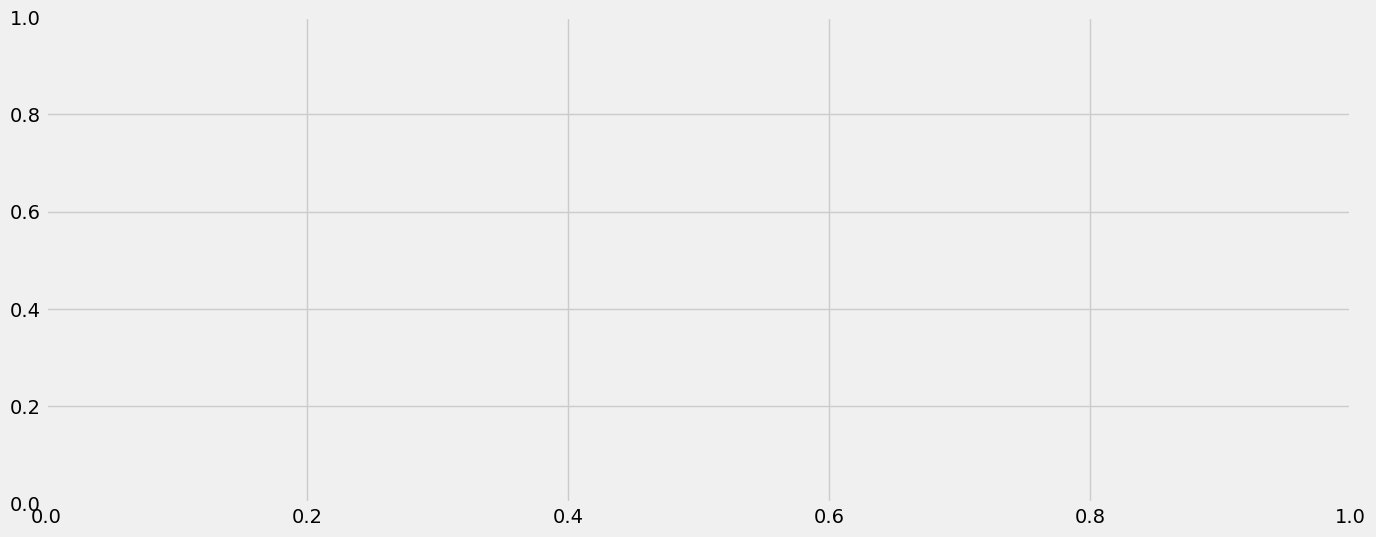

In [24]:
plt.figure(figsize=(15,6))

plt.plot(range(1,11), future_predictions, marker="o", label='Future Price Prediction', linewidth=2)

for i, val in enumerate(future_predictions):
    plt.text(i+1, val, f'{val:.2f}', fontsize=10, ha='center')

plt.title("Future Ethereum Prices for 10 Days", fontsize=16)
plt.xlabel("Day Ahead")
plt.ylabel("Price")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [25]:
future_predictions = np.array(future_predictions).flatten()

In [27]:
future_predictions = np.array(future_predictions).reshape(-1)

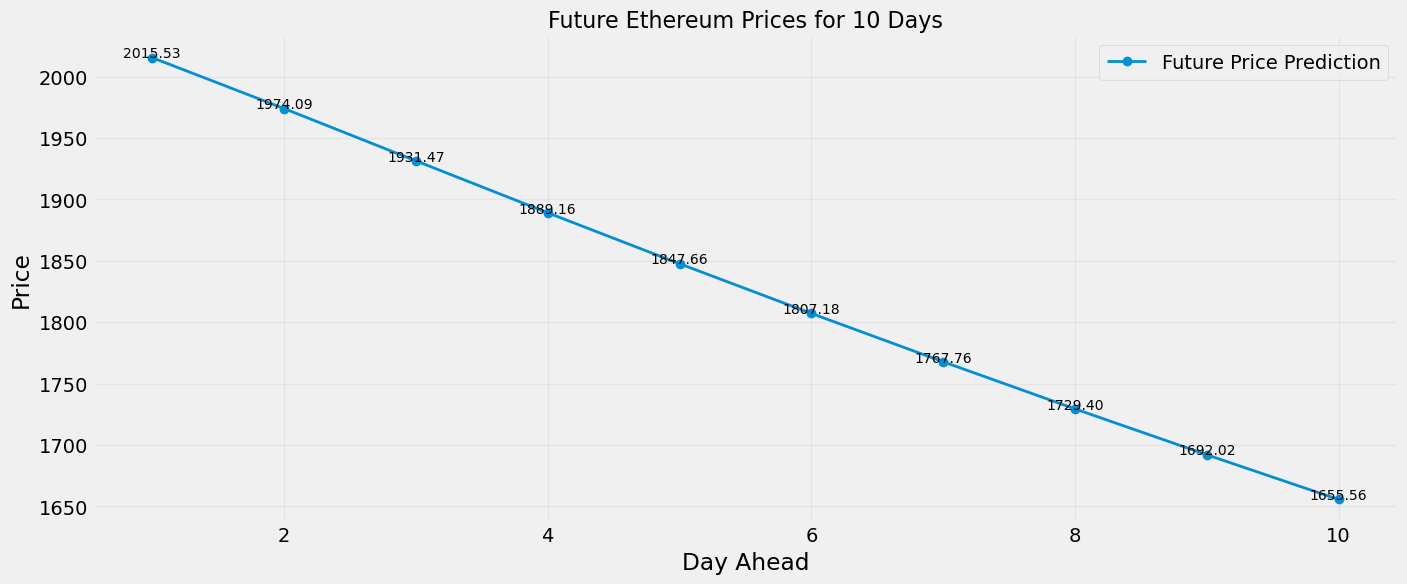

In [29]:
plt.figure(figsize=(15,6))

plt.plot(range(1,11), future_predictions, marker="o", label='Future Price Prediction', linewidth=2)

for i, val in enumerate(future_predictions):
    plt.text(i+1, val, f'{val:.2f}', fontsize=10, ha='center')

plt.title("Future Ethereum Prices for 10 Days", fontsize=16)
plt.xlabel("Day Ahead")
plt.ylabel("Price")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [31]:
future_predictions = []

for _ in range(10):

    next_day = model.predict(last_100)

    future_predictions.append(next_day[0][0])   # FIX

    last_100 = np.append(last_100[:,1:,:], next_day.reshape(1,1,1), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [33]:
model.save("ethereum_price_model.keras")

In [35]:
model.save("ethereum_price_model.h5")